In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize
# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [4]:
Nt=192

In [5]:
gsq=0.050000
beta=1.0/gsq

In [6]:
T=16
Nt=240

In [9]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

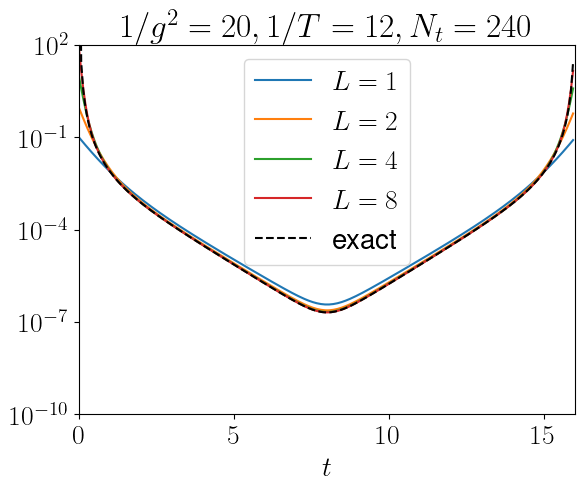

In [10]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [80]:
def fitter( x, m, A ):
    return 2.0 * A * np.exp(-m*8.0) * np.cosh( -m*(x-8.0) )

In [81]:
masses_=[]

In [82]:
xx=T * np.arange(Nt)/Nt
yy=np.copy(l1_1)

(1e-06, 100.0)

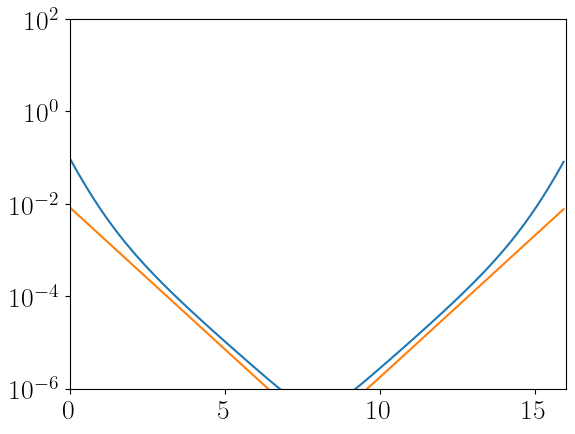

In [83]:
plt.plot(xx, yy)

yy1 = fitter(xx, np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi) )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, T)
plt.ylim(1.0e-6, 1.0e2)

In [84]:
fitm = int(7.5 * Nt/12)
fitM = int(8.5 * Nt/12)

In [85]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                       p0=(np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi)), 
                       full_output=True, absolute_sigma=True )

In [86]:
masses_.append(opt[0][0])

(1e-06, 100.0)

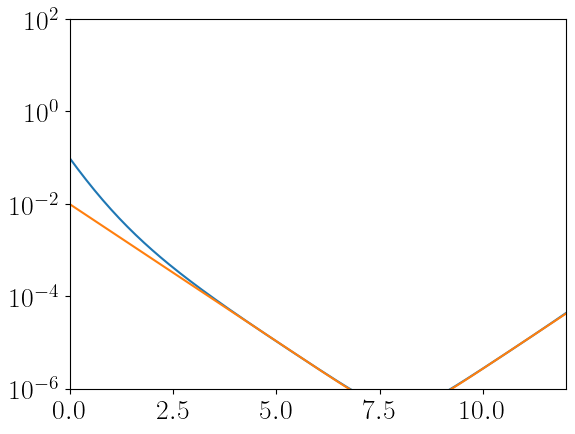

In [87]:
plt.plot(xx, yy)

yy1 = fitter(xx, opt[0][0], opt[0][1] )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-6, 1.0e2)

In [88]:
yy=np.copy(l2_1)

(1e-06, 100.0)

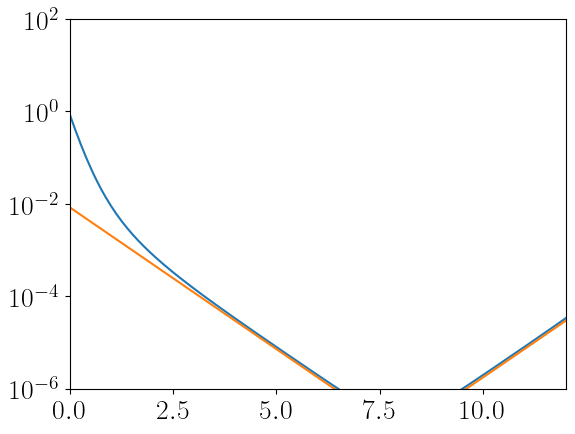

In [89]:
plt.plot(xx, yy)

yy1 = fitter(xx, np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi) )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-6, 1.0e2)

In [90]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                       p0=(np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi)), 
                       full_output=True, absolute_sigma=True )

In [91]:
masses_.append(opt[0][0])

(1e-06, 100.0)

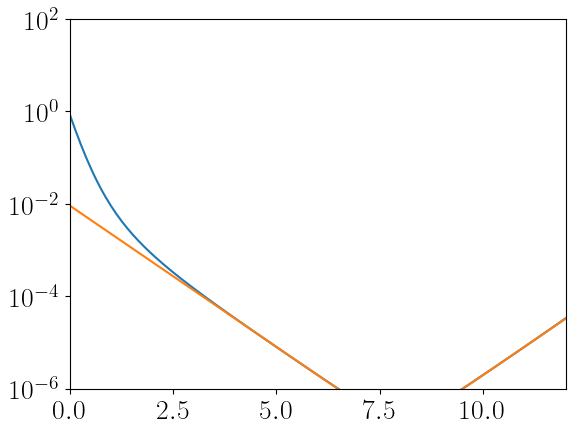

In [92]:
plt.plot(xx, yy)

yy1 = fitter(xx, opt[0][0], opt[0][1] )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-6, 1.0e2)

In [93]:
yy=np.copy(l4_1)

(1e-08, 100.0)

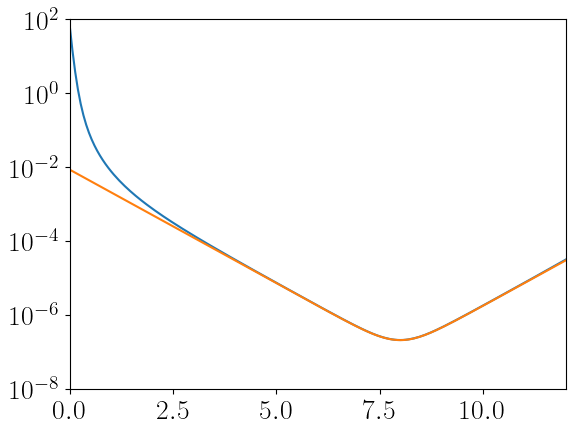

In [106]:
plt.plot(xx, yy)

yy1 = fitter(xx, np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi) )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-8, 1.0e2)

In [95]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                       p0=(np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi)), 
                       full_output=True, absolute_sigma=True )

In [96]:
masses_.append(opt[0][0])

(1e-08, 100.0)

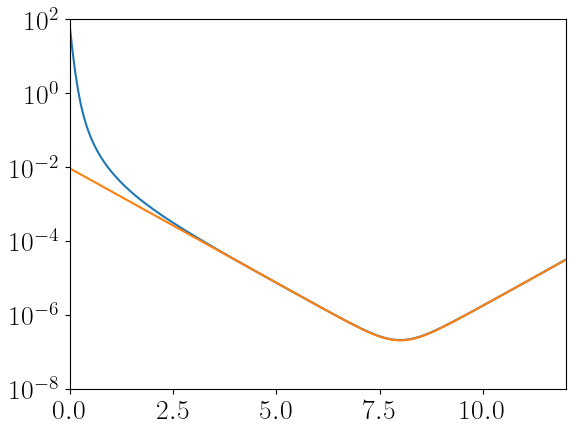

In [107]:
plt.plot(xx, yy)

yy1 = fitter(xx, opt[0][0], opt[0][1] )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-8, 1.0e2)

In [98]:
yy=np.copy(l8_1)

(1e-08, 100.0)

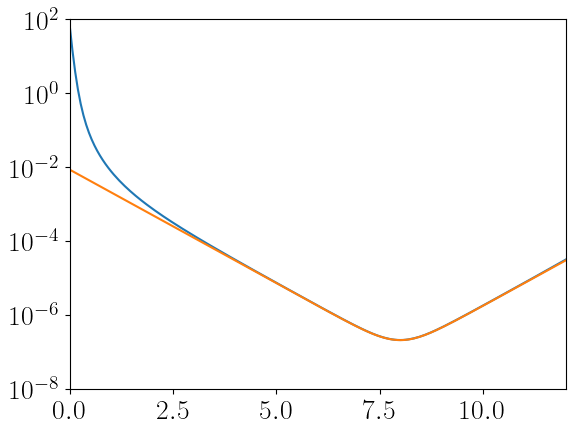

In [108]:
plt.plot(xx, yy)

yy1 = fitter(xx, np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi) )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-8, 1.0e2)

In [100]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                       p0=(np.sqrt(2.0), (1.0/beta)*3.0*np.sqrt(2.0)/(8.0*np.pi)), 
                       full_output=True, absolute_sigma=True )

In [101]:
masses_.append(opt[0][0])

(1e-06, 100.0)

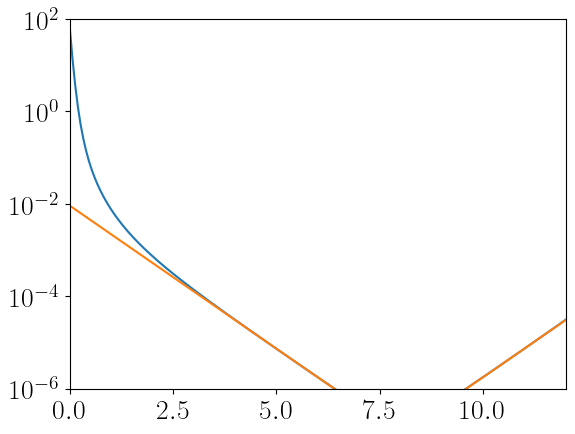

In [102]:
plt.plot(xx, yy)

yy1 = fitter(xx, opt[0][0], opt[0][1] )
plt.plot(xx, yy1)

plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1.0e-6, 1.0e2)

In [103]:
masses = np.array(masses_)

In [104]:
np.sqrt(2.0)

1.4142135623730951

In [ ]:
plt.plot(masses)

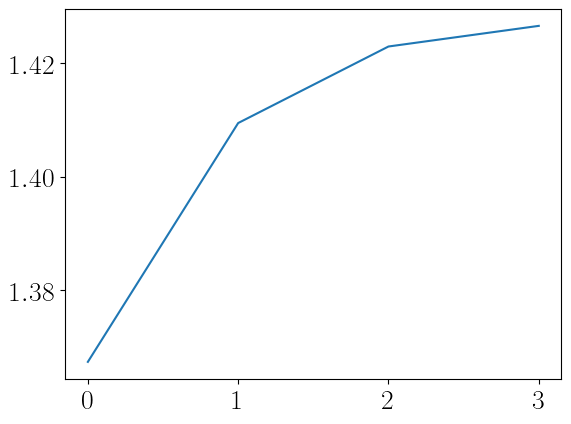

In [105]:
plt.plot(masses)

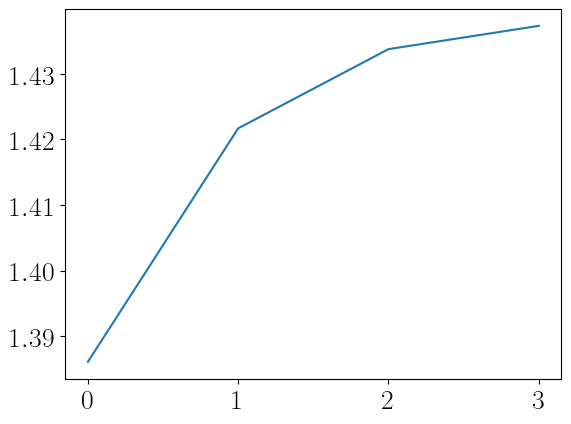

In [49]:
plt.plot(masses)

In [74]:
1.42512816

1.42512816

In [37]:
xx[fitm:fitM+1]
yy[fitm:fitM+1]

array([1.13129e-05, 1.05035e-05, 9.77231e-06, 9.11352e-06, 8.52201e-06,
       7.99320e-06, 7.52299e-06, 7.10776e-06, 6.74432e-06, 6.42989e-06,
       6.16206e-06, 5.93878e-06, 5.75837e-06, 5.61945e-06, 5.52097e-06,
       5.46217e-06, 5.44262e-06, 5.46217e-06, 5.52097e-06, 5.61945e-06,
       5.75837e-06, 5.93878e-06, 6.16206e-06, 6.42989e-06, 6.74432e-06,
       7.10776e-06, 7.52299e-06, 7.99320e-06, 8.52201e-06, 9.11352e-06,
       9.77231e-06, 1.05035e-05, 1.13129e-05])

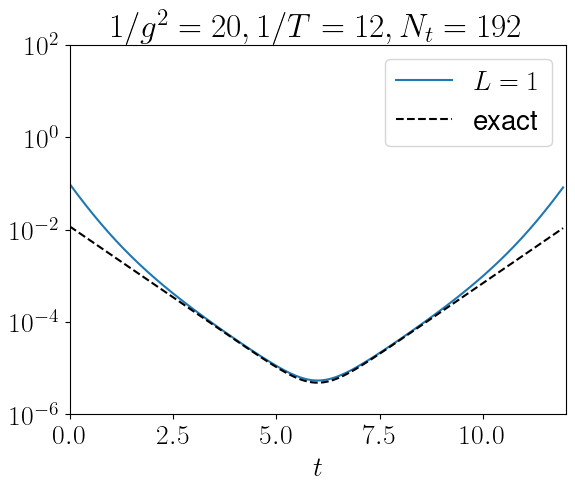

In [20]:
plt.yscale("log")

xx=12 * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )

yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
plt.plot( xx, 1.4*yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t=Nt$")

plt.xlim(0, 12)
plt.ylim(1.0e-6, 1.0e2)
plt.legend()

In [44]:
at = T/Nt

In [120]:
l8_1

array([6.90745e+01, 1.43621e+01, 3.74218e+00, 1.24236e+00, 5.11380e-01,
       2.49411e-01, 1.38201e-01, 8.41974e-02, 5.50533e-02, 3.79696e-02,
       2.72846e-02, 2.02506e-02, 1.54262e-02, 1.20048e-02, 9.51041e-03,
       7.64884e-03, 6.23163e-03, 5.13399e-03, 4.27100e-03, 3.58348e-03,
       3.02933e-03, 2.57799e-03, 2.20694e-03, 1.89935e-03, 1.64242e-03,
       1.42634e-03, 1.24348e-03, 1.08786e-03, 9.54729e-04, 8.40308e-04,
       7.41540e-04, 6.55947e-04, 5.81501e-04, 5.16535e-04, 4.59667e-04,
       4.09747e-04, 3.65811e-04, 3.27050e-04, 2.92777e-04, 2.62411e-04,
       2.35455e-04, 2.11484e-04, 1.90133e-04, 1.71087e-04, 1.54072e-04,
       1.38854e-04, 1.25225e-04, 1.13006e-04, 1.02041e-04, 9.21894e-05,
       8.33320e-05, 7.53612e-05, 6.81829e-05, 6.17135e-05, 5.58792e-05,
       5.06144e-05, 4.58606e-05, 4.15661e-05, 3.76844e-05, 3.41743e-05,
       3.09987e-05, 2.81246e-05, 2.55225e-05, 2.31658e-05, 2.10306e-05,
       1.90955e-05, 1.73413e-05, 1.57506e-05, 1.43078e-05, 1.299

In [128]:
Nt

240

In [124]:
int(Nt*T/2)

1920

In [ ]:
np.arccosh(l8_1)

In [129]:
l8_1[int(Nt/2)]

2.06914e-07

In [156]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [180]:
Nt

240

In [211]:
fitm = int(3.0 * Nt/T)
fitM = int(7.0 * Nt/T)

In [212]:
fitm, fitM

(45, 105)

In [213]:
def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [225]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

In [226]:
opt[0]

array([1.41261992, 1.070428  , 3.39049219])

(0.0, 2.0)

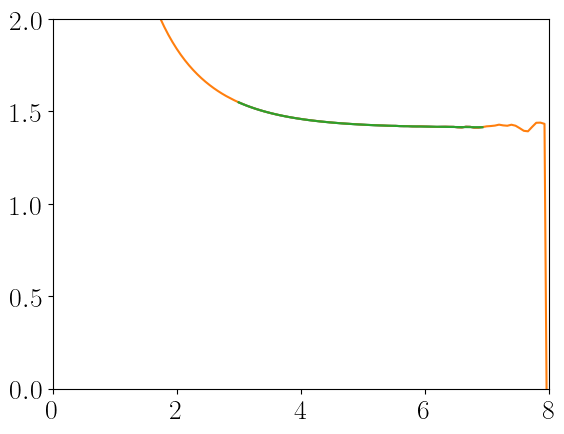

In [227]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

(0.0, 2.0)

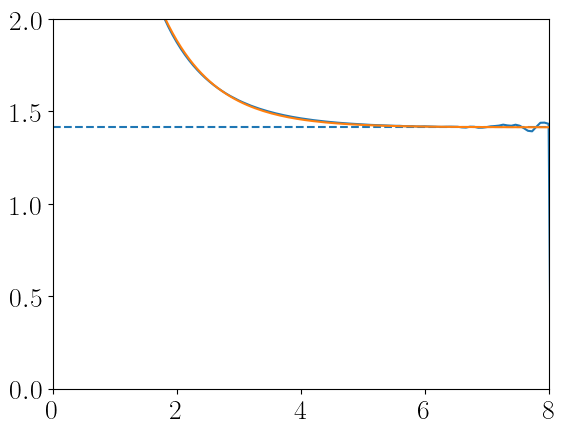

In [166]:
yy = (-tmp[1:]+tmp[:-1])/at
plt.plot(xx[1:], yy)

plt.hlines( np.sqrt(2.0), 0, T/2, ls="dashed" )
plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

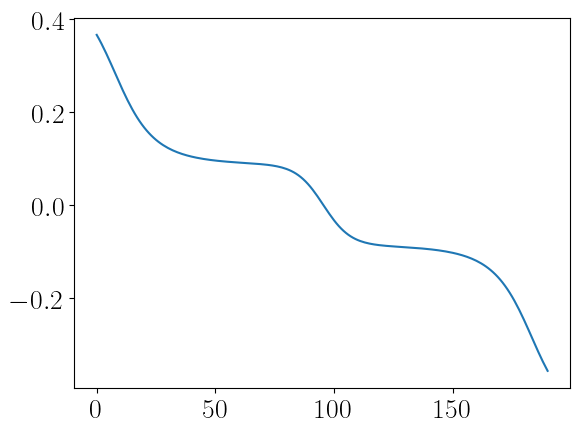

In [12]:
plt.plot( -np.log(l2_1[1:]/l2_1[:-1]) )

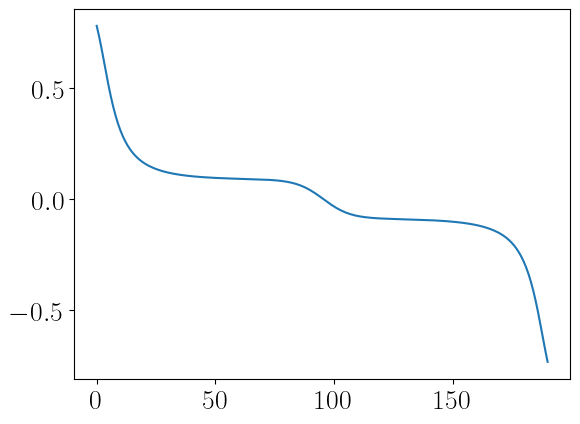

In [13]:
plt.plot( -np.log(l4_1[1:]/l4_1[:-1]) )

In [8]:
# gsq=2.00000
# beta=1.0/gsq

# key_1='gsq2.000000at0.500000nt24L1__corr'
# key_2='gsq2.000000at0.500000nt24L2__corr'
# # key_4='gsq0.500000at0.375000nt32L4_'

# l1_1 = np.loadtxt("corr_"+key_1+".dat")
# l1_2 = np.loadtxt("corr_"+key_2+".dat")
# # l1_4 = np.loadtxt("corr_"+key_4+".dat")

In [9]:
# plt.yscale("log")

# xx=np.arange(24)*0.5000
# plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
# plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
# # plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

# xx=np.linspace(0, 12, 5000)

# yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

# yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='red', label='exact' )

# plt.xlabel("$t$")
# plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

# plt.xlim(0, 12)
# plt.ylim(1.0e-5, 1.0e2)
# plt.legend()

# # plt.savefig("jtjt.pdf")

In [12]:
key_1='gsq0.500000at0.500000nt24L1__corr'
key_2='gsq0.500000at0.500000nt24L2__corr'
key_4='gsq0.500000at0.500000nt24L4__corr'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
l1_4 = np.loadtxt("corr_"+key_4+".dat")

FileNotFoundError: corr_gsq0.500000at0.500000nt24L4__corr.dat not found.

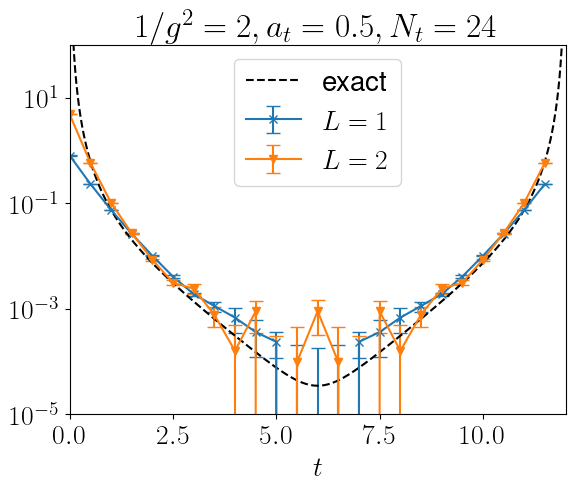

In [11]:
plt.yscale("log")

xx=np.arange(24)*0.5000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
# plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

# yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='red', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 2, a_t=0.5, N_t=24$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

plt.savefig("jtjt_Nt24.pdf")

In [42]:
key_1='gsq0.500000at0.500000nt24L1__meff'
key_2='gsq0.500000at0.500000nt24L2__meff'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

(-2.0, 7.0)

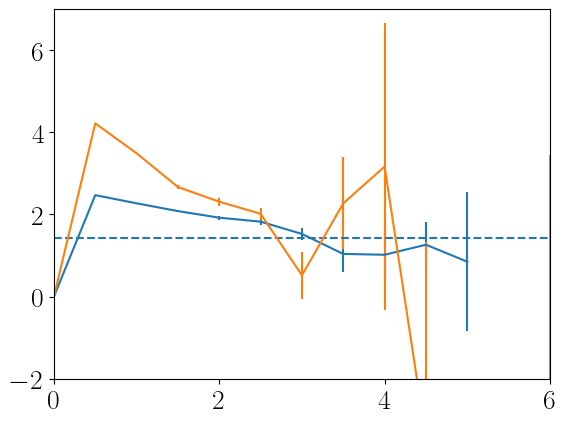

In [30]:
xx=np.arange(24)*0.5000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1] )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1] )
plt.hlines( np.sqrt(2.0), 0, 6, ls='dashed' )
plt.xlim(0,6)
plt.ylim(-2,7)

In [43]:
key_1='gsq0.500000at0.375000nt32L1__corr'
key_2='gsq0.500000at0.375000nt32L2__corr'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

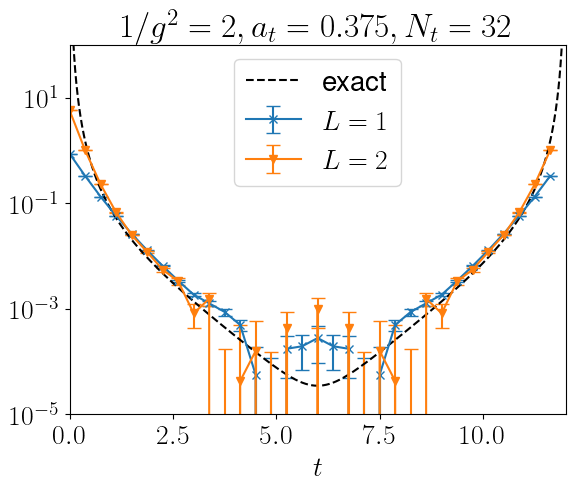

In [44]:
plt.yscale("log")

xx=np.arange(32)*0.375000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
# plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

# yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='red', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 2, a_t=0.375, N_t=32$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

plt.savefig("jtjt_Nt32.pdf")

In [33]:
key_1='gsq0.500000at0.375000nt32L1__meff'
key_2='gsq0.500000at0.375000nt32L2__meff'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

(-2.0, 7.0)

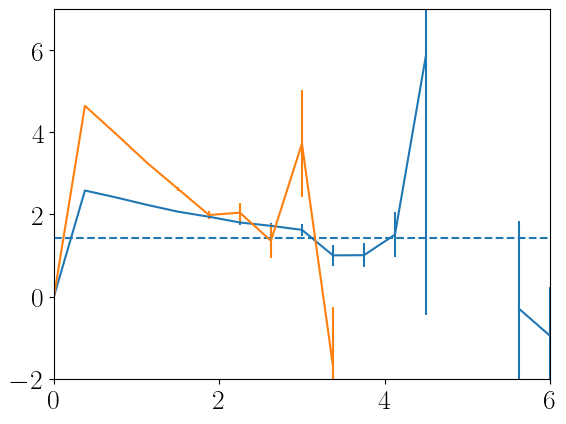

In [34]:
xx=np.arange(32)*0.375000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1] )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1] )
plt.hlines( np.sqrt(2.0), 0, 6, ls='dashed' )
plt.xlim(0,6)
plt.ylim(-2,7)

In [25]:
key_1='gsq0.500000at0.250000nt48L1__corr'
key_2='gsq0.500000at0.250000nt48L2__corr'
key_4='gsq0.500000at0.250000nt48L4__corr'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
l1_4 = np.loadtxt("corr_"+key_4+".dat")

In [13]:
binsize=100

In [ ]:
plt.yscale("log")

xx=np.arange(48)*0.25
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [26]:
l1_4

array([[ 2.58567e+01,  1.34919e+00],
       [ 3.08479e+00,  1.60966e-01],
       [ 5.51226e-01,  2.87768e-02],
       [ 1.51047e-01,  7.93309e-03],
       [ 5.93289e-02,  3.22455e-03],
       [ 3.15004e-02,  2.00753e-03],
       [ 1.63628e-02,  1.24101e-03],
       [ 7.25426e-03,  1.02069e-03],
       [ 3.06745e-03,  1.06143e-03],
       [ 1.46954e-05,  8.76100e-04],
       [-8.55911e-04,  1.00474e-03],
       [ 1.69758e-04,  9.64366e-04],
       [-3.48861e-04,  9.06459e-04],
       [ 2.80285e-03,  9.75635e-04],
       [ 3.59740e-03,  1.10333e-03],
       [ 2.56943e-03,  9.23602e-04],
       [ 2.84282e-03,  1.01567e-03],
       [-1.56302e-04,  8.19089e-04],
       [-9.99339e-04,  1.03418e-03],
       [-4.02704e-03,  9.82837e-04],
       [-3.54848e-03,  1.02323e-03],
       [-2.90794e-04,  9.19606e-04],
       [ 1.35805e-03,  8.99457e-04],
       [ 8.94548e-04,  7.69531e-04],
       [ 2.73321e-03,  1.39947e-03],
       [ 8.94548e-04,  7.69531e-04],
       [ 1.35805e-03,  8.99457e-04],
 

In [20]:
l1_4

array([[ 3.91890e+01,  1.04023e-01],
       [ 4.67528e+00,  1.23822e-02],
       [ 8.35318e-01,  2.77511e-03],
       [ 2.29001e-01,  1.68260e-03],
       [ 8.98009e-02,  1.45274e-03],
       [ 4.78226e-02,  1.99381e-03],
       [ 2.50659e-02,  1.44156e-03],
       [ 1.11009e-02,  1.59928e-03],
       [ 4.57388e-03,  1.69327e-03],
       [-2.16450e-04,  1.35749e-03],
       [-1.29176e-03,  1.74603e-03],
       [ 4.26626e-04,  1.58079e-03],
       [-5.45515e-04,  1.48398e-03],
       [ 4.18315e-03,  1.56814e-03],
       [ 5.55080e-03,  1.69779e-03],
       [ 3.83686e-03,  1.51308e-03],
       [ 4.38214e-03,  1.70357e-03],
       [-4.12958e-04,  1.30468e-03],
       [-1.83008e-03,  1.75276e-03],
       [-5.94236e-03,  1.55223e-03],
       [-5.51766e-03,  1.61519e-03],
       [-2.71268e-04,  1.49109e-03],
       [ 2.21970e-03,  1.45413e-03],
       [ 1.09788e-03,  1.14711e-03],
       [ 4.38789e-03,  2.14837e-03],
       [ 1.09788e-03,  1.14711e-03],
       [ 2.21970e-03,  1.45413e-03],
 

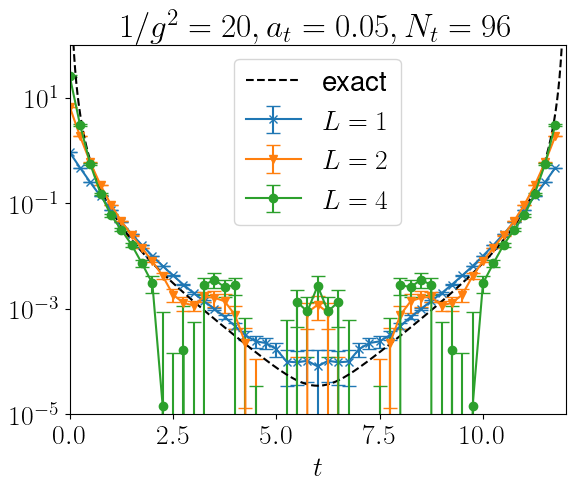

In [27]:
plt.yscale("log")

xx=np.arange(48)*0.25
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [15]:
binsize=2000

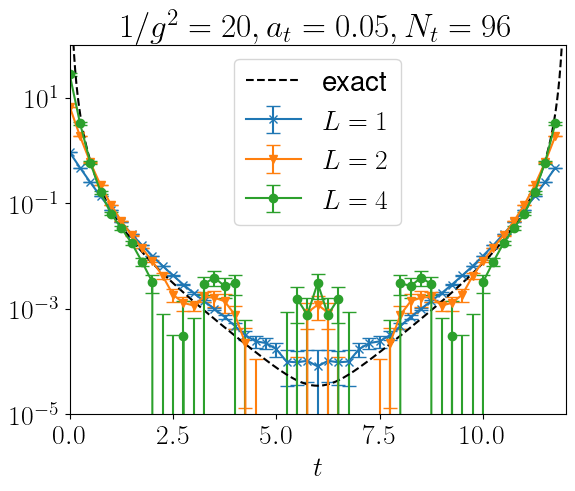

In [16]:
plt.yscale("log")

xx=np.arange(48)*0.25
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [39]:
key_1='gsq0.500000at0.250000nt48L1__meff'
key_2='gsq0.500000at0.250000nt48L2__meff'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

(-2.0, 7.0)

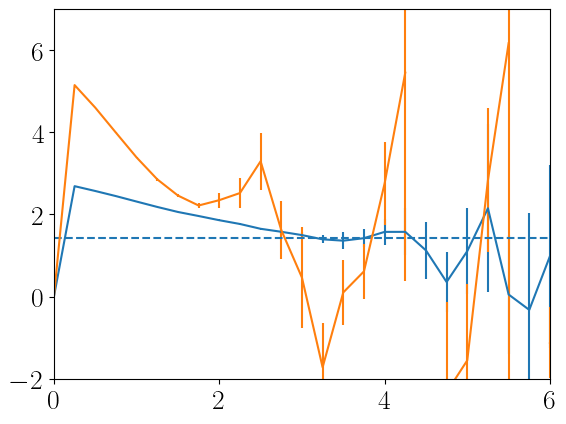

In [40]:
xx=np.arange(48)*0.25000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1] )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1] )
plt.hlines( np.sqrt(2.0), 0, 6, ls='dashed' )
plt.xlim(0,6)
plt.ylim(-2,7)

In [16]:
at=0.25

/scratch/354095.1.ood/ipykernel_2309507/2497384176.py:1: RuntimeWarning: divide by zero encountered in divide
  meff = -np.log( l1_1.T[0][1:]/l1_1.T[0][:-1] )
/scratch/354095.1.ood/ipykernel_2309507/2497384176.py:1: RuntimeWarning: invalid value encountered in log
  meff = -np.log( l1_1.T[0][1:]/l1_1.T[0][:-1] )


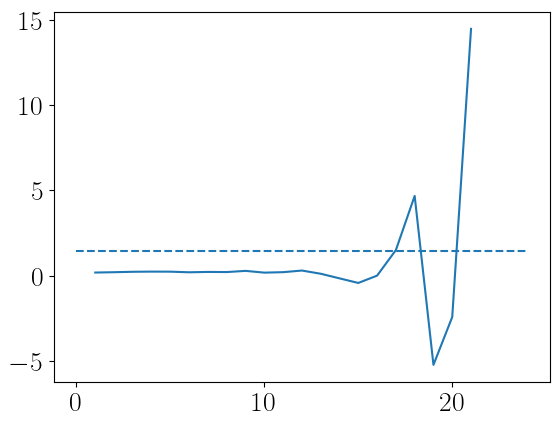

In [17]:
meff = -np.log( l1_1.T[0][1:]/l1_1.T[0][:-1] )

plt.plot( meff[:24]/at )
plt.hlines( np.sqrt(2.0), 0, 24, ls='dashed' )

/scratch/354095.1.ood/ipykernel_2309507/2068367678.py:1: RuntimeWarning: divide by zero encountered in divide
  meff = -np.log( l1_2.T[0][1:]/l1_2.T[0][:-1] )
/scratch/354095.1.ood/ipykernel_2309507/2068367678.py:1: RuntimeWarning: invalid value encountered in log
  meff = -np.log( l1_2.T[0][1:]/l1_2.T[0][:-1] )


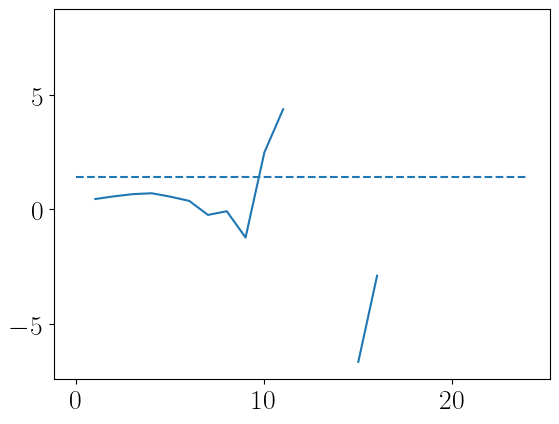

In [18]:
meff = -np.log( l1_2.T[0][1:]/l1_2.T[0][:-1] )

plt.plot( meff[:24]/at )
plt.hlines( np.sqrt(2.0), 0, 24, ls='dashed' )

In [10]:
96

96

In [13]:
at=0.050000
beta=20

key_2_1='gsq0.050000at0.100000nt48L2_'
key_2_2='gsq0.050000at0.075000nt64L2_'
key_2_3='gsq0.050000at0.050000nt96L2_'

In [14]:
l1_1 = np.loadtxt("corr_"+key_2_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2_2+".dat")
# l1_3 = np.loadtxt("corr_"+key_3+".dat")
l1_4 = np.loadtxt("corr_"+key_2_3+".dat")
# l2 = np.loadtxt("corr_"+key+"nt96L2_short.dat")
# l4 = np.loadtxt("corr_"+key+"nt96L4_short.dat")

/scratch/352694.1.ood/ipykernel_470825/2989030815.py:1: UserWarning: loadtxt: input contained no data: "corr_gsq0.050000at0.100000nt48L2_.dat"
  l1_1 = np.loadtxt("corr_"+key_2_1+".dat")


IndexError: index 0 is out of bounds for axis 0 with size 0

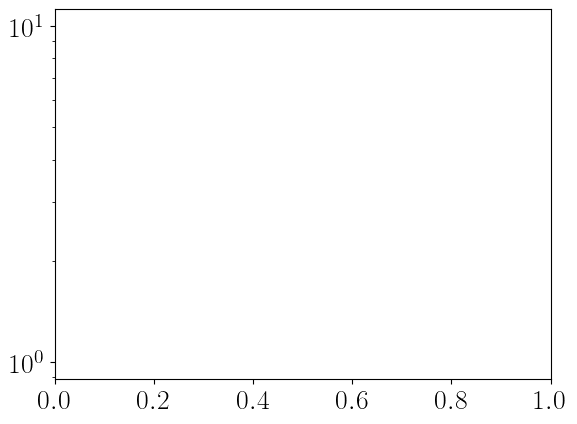

In [15]:
plt.yscale("log")

xx=np.arange(48)*0.100000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
xx=np.arange(64)*0.075000
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
xx=np.arange(96)*0.050000
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 4.8, 5000)

yy= (1.0/beta)*f(xx, 4000, 4.8) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 5)
plt.ylim(1.0e-4, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [ ]:
l1 = np.loadtxt("corr_beta5.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta5.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta5.000000at0.100000nt96L4.dat")

(0.0, 4.0)

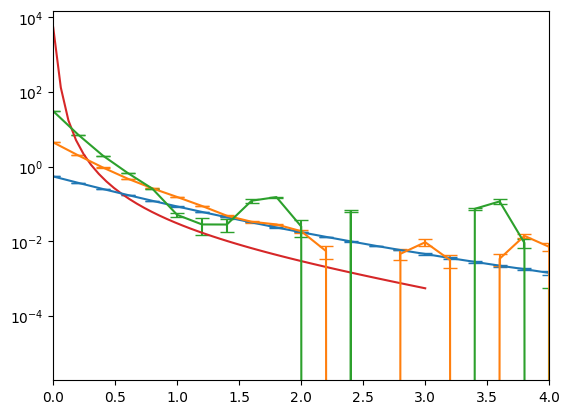

In [7]:
plt.yscale("log")

xx=np.arange(96)*0.2
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=1" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

# yy= (1.0/300.0)*f(xx, 6)
# plt.plot( xx, yy )

# yy= (1.0/800.0)*f(xx, 11)
# plt.plot( xx, yy )

# yy= (1.0/800.0)*f(xx, 20)
# plt.plot( xx, yy )

yy= (1.0/5.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

In [8]:
l1 = np.loadtxt("corr_beta20.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta20.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta20.000000at0.100000nt96L4.dat")

(0.0, 4.0)

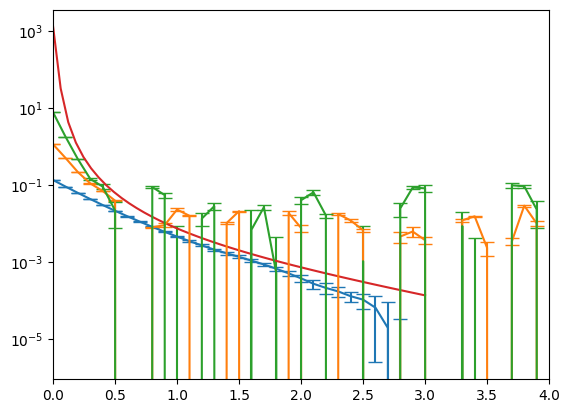

In [10]:
plt.yscale("log")

xx=np.arange(96)*0.1
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=1" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

# yy= (1.0/20.0)*f(xx, 6)
# plt.plot( xx, yy )

# yy= (1.0/20.0)*f(xx, 11)
# plt.plot( xx, yy )

# yy= (1.0/20.0)*f(xx, 20)
# plt.plot( xx, yy )

yy= (1.0/20.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

In [11]:
l1 = np.loadtxt("corr_beta50.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta50.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta50.000000at0.100000nt96L4.dat")

(0.0, 4.0)

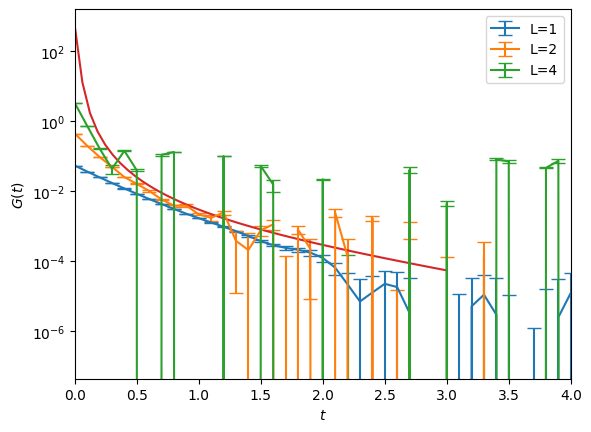

In [15]:
plt.yscale("log")

xx=np.arange(96)*0.1
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=2" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=4" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

# yy= (1.0/50.0)*f(xx, 6)
# plt.plot( xx, yy )

# yy= (1.0/50.0)*f(xx, 11)
# plt.plot( xx, yy )

# yy= (1.0/50.0)*f(xx, 20)
# plt.plot( xx, yy )

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$G(t)$")

yy= (1.0/50.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

In [17]:
l1 = np.loadtxt("corr_beta50.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta50.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta50.000000at0.100000nt96L4.dat")

(0.0, 4.0)

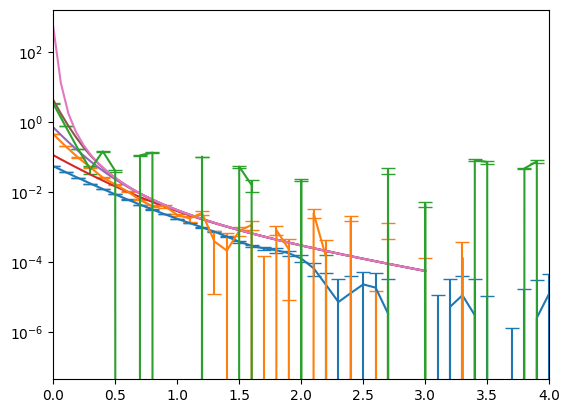

In [19]:
plt.yscale("log")

xx=np.arange(96)*0.1
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=1" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

yy= (1.0/50.0)*f(xx, 6)
plt.plot( xx, yy )

yy= (1.0/50.0)*f(xx, 11)
plt.plot( xx, yy )

yy= (1.0/50.0)*f(xx, 20)
plt.plot( xx, yy )

yy= (1.0/50.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

(1e-05, 1.0)

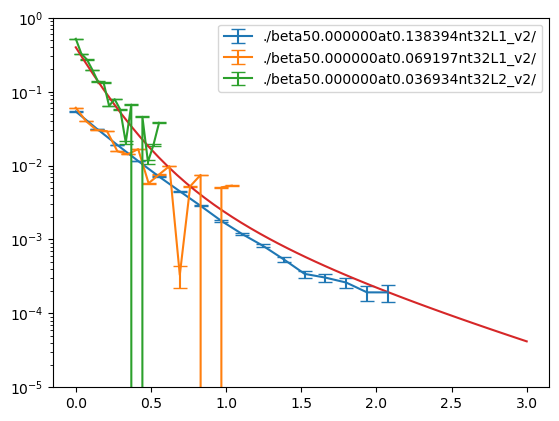

In [26]:
plt.yscale("log")

for res in res_list:
    Nt = res[1].shape[0]

    at = float(res[0].split("at")[1].split("nt")[0])
    xx=np.arange(int(Nt/2)) * at
    # xx=np.arange(Nt)
    yy=res[1][:int(Nt/2)]
    dy=res[2][:int(Nt/2)]

    plt.errorbar( xx, yy, dy, capsize=5, label=res[0] )

# xx=np.arange(Nt)
# yy= 0.07*np.exp( -np.sqrt(2.0) * xx / 8.0 )
# plt.plot( xx, yy )

xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )
yy= 0.0006*f(xx, 10)
plt.plot( xx, yy )



plt.legend()
plt.ylim( 1.0e-5, 1.0e0 )

In [7]:
l1

array([[ 1.36846e-01,  3.83936e-04],
       [ 9.27521e-02,  3.81009e-04],
       [ 6.35540e-02,  3.64255e-04],
       [ 4.40706e-02,  3.48425e-04],
       [ 3.09533e-02,  3.38998e-04],
       [ 2.19969e-02,  3.24321e-04],
       [ 1.58502e-02,  3.09281e-04],
       [ 1.15498e-02,  2.98567e-04],
       [ 8.51418e-03,  2.89944e-04],
       [ 6.34319e-03,  2.94173e-04],
       [ 4.79504e-03,  2.88819e-04],
       [ 3.69040e-03,  2.76160e-04],
       [ 2.90254e-03,  2.59906e-04],
       [ 2.33086e-03,  2.29066e-04],
       [ 1.94455e-03,  2.04223e-04],
       [ 1.64468e-03,  1.87646e-04],
       [ 1.36795e-03,  1.69771e-04],
       [ 1.12203e-03,  1.53549e-04],
       [ 8.84507e-04,  1.36835e-04],
       [ 6.72361e-04,  1.29129e-04],
       [ 5.04484e-04,  1.35618e-04],
       [ 3.68713e-04,  1.38841e-04],
       [ 2.98513e-04,  1.27299e-04],
       [ 2.50617e-04,  9.39149e-05],
       [ 2.07537e-04,  6.65377e-05],
       [ 1.90550e-04,  7.68855e-05],
       [ 1.60900e-04,  1.10202e-04],
 

In [3]:
res_list=[]

binsize=10

In [4]:
path="./beta50.000000at0.138394nt32L1_v2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [5]:
path="./beta50.000000at0.069197nt32L1_v2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [6]:
path="./beta50.000000at0.036934nt32L2_v2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [7]:
res_list

[['./beta50.000000at0.138394nt32L1_v2/',
  array([0.05378207, 0.03163215, 0.0189523 , 0.01149634, 0.00708858,
         0.00448384, 0.00284665, 0.00177947, 0.00118273, 0.00081948,
         0.00053707, 0.00034221, 0.00030449, 0.00026111, 0.00019233,
         0.00019217, 0.00022491, 0.00019217, 0.00019233, 0.00026111,
         0.00030449, 0.00034221, 0.00053707, 0.00081948, 0.00118273,
         0.00177947, 0.00284665, 0.00448384, 0.00708858, 0.01149634,
         0.0189523 , 0.03163215]),
  array([5.21833502e-05, 4.74696688e-05, 4.24059908e-05, 3.93463202e-05,
         3.80315951e-05, 3.66643497e-05, 3.50076707e-05, 3.55485093e-05,
         3.59880843e-05, 3.66644322e-05, 3.60388806e-05, 3.70653828e-05,
         3.84997536e-05, 3.98424565e-05, 4.31942074e-05, 4.88073469e-05,
         5.25850352e-05, 4.88073469e-05, 4.31942074e-05, 3.98424565e-05,
         3.84997536e-05, 3.70653828e-05, 3.60388806e-05, 3.66644322e-05,
         3.59880843e-05, 3.55485093e-05, 3.50076707e-05, 3.66643497e-05,

In [14]:
def f(t, nmax):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
    return res

In [22]:
Nt

32

(1e-05, 1.0)

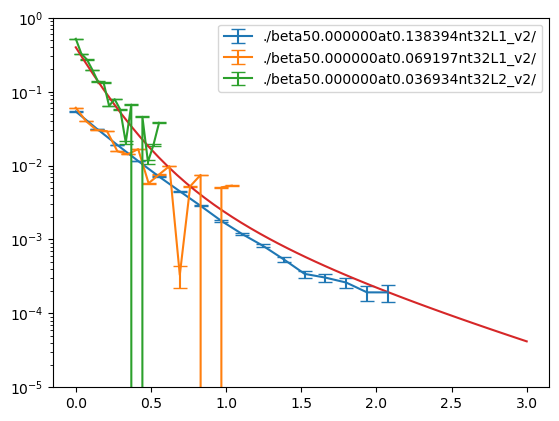

In [26]:
plt.yscale("log")

for res in res_list:
    Nt = res[1].shape[0]

    at = float(res[0].split("at")[1].split("nt")[0])
    xx=np.arange(int(Nt/2)) * at
    # xx=np.arange(Nt)
    yy=res[1][:int(Nt/2)]
    dy=res[2][:int(Nt/2)]

    plt.errorbar( xx, yy, dy, capsize=5, label=res[0] )

# xx=np.arange(Nt)
# yy= 0.07*np.exp( -np.sqrt(2.0) * xx / 8.0 )
# plt.plot( xx, yy )

xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )
yy= 0.0006*f(xx, 10)
plt.plot( xx, yy )



plt.legend()
plt.ylim( 1.0e-5, 1.0e0 )

In [9]:
50.0/8.0

6.25